# TABLE - Phát hiện và xử lý ngoại lai

# Mục lục
1. [Lý thuyết](#sec-1)
   - 1.1. [Tổng quan về ngoại lai (Outliers)](#sec-1-1)
      - 1.1.1. [Ngoại lai là gì?](#sec-1-1-1)
      - 1.1.2. [Ngoại lai là dữ liệu sai (Error) hay Insight giá trị?](#sec-1-1-2)
      - 1.1.3. [Phân loại, nguyên lý và đặc tính các phương pháp](#sec-1-1-3)
   - 1.2. [Đi sâu vào phương pháp thống kê: Z-Score và IQR](#sec-1-2)
      - 1.2.1. [Dữ liệu có cần phân phối chuẩn không và vì sao?](#sec-1-2-1)
      - 1.2.2. [IQR và Z-score khác nhau điểm nào? Khi dữ liệu lệch thì dùng gì tốt hơn?](#sec-1-2-2)
      - 1.2.3. [Ngưỡng $|IQR * 1.5|$ và $|Z| > 3$ có luôn đúng không? Biện luận?](#sec-1-2-3)
   - 1.3. [Nhóm phương pháp máy học: Isolation Forest](#sec-1-3)
   - 1.4. [Nhóm Phương pháp Mật độ: Local Outlier Factor (LOF)](#sec-1-4)
   - 1.5. [Phương pháp Gom cụm: DBSCAN](#sec-1-5)
2. [Thực nghiệm và nhận xét](#sec-2)
   - 2.1. [Thống kê tỉ lệ phần trăm ngoại lai được phát hiện qua 5 phương pháp](#sec-2-1)
   - 2.2. [Phân tích Độ chồng chéo và Phân nhóm cho các thuật toán](#sec-2-2)


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from collections import Counter
import time

from config import settings
from utils.file import jaccard_similarity 
from table.dataset import TableDataset
from table.preprocessing_detect_outlier import (
    IQR_Outlier, ZScore_Outlier, IForest_Outlier, LOF_Outlier, DBSCAN_Outlier
)
from statistic.test_distribution import KolmogorovSmirnovTesting

<a id="sec-1"></a>

# 1. Lý thuyết

<a id="sec-1-1"></a>

## 1.1. Tổng quan về ngoại lai (Outliers)

<a id="sec-1-1-1"></a>

### 1.1.1. Ngoại lai là gì?
Ngoại lai là những điểm dữ liệu có giá trị hoặc tính chất khác biệt một cách đáng kể, lệch hẳn so với xu hướng phân bố chung của phần lớn dữ liệu còn lại trong tập Giấy phép xây dựng.

<a id="sec-1-1-2"></a>

### 1.1.2. Ngoại lai là dữ liệu sai (Error) hay Insight giá trị?
Trong thực tế, ngoại lai có thể là **cả hai**, và việc xác định phụ thuộc vào Domain Knowledge:
* **Ngoại lai là dữ liệu sai:** Đó là những lỗi do con người nhập liệu hoặc lỗi hệ thống. *Ví dụ:* Tòa nhà có Số tầng (`Number of Stories`) là `-5` (giá trị âm vô lý), hoặc Chi phí dự toán (`Estimated Cost`) là `$0` cho một tòa nhà 50 tầng. $\rightarrow$ **Cần loại bỏ hoặc sửa chữa.**
* **Ngoại lai là Insight:** Đó là những giá trị tuy rất hiếm gặp nhưng hoàn toàn hợp lý và mang tính đột phá. *Ví dụ:* Hầu hết giấy phép là để sửa chữa nhà dân (giá vài chục ngàn đô), nhưng bỗng xuất hiện một dự án xây dựng tòa nhà chọc trời của Apple/Google trị giá hàng tỷ đô la. Nó là một dự án đặc biệt, không phải lỗi. $\rightarrow$ **Việc loại bỏ các điểm này có thể làm mất đi thông tin quan trọng về các siêu dự án của thành phố.**

<a id="sec-1-1-3"></a>

### 1.1.3. Phân loại, Nguyên lý và Đặc tính các phương pháp

| Phương pháp | Thuộc nhóm | Nguyên lý hoạt động (Dựa vào đâu?) | Phù hợp với loại dữ liệu | Nhạy cảm với tham số/dữ liệu? |
| :--- | :--- | :--- | :--- | :--- |
| **Z-Score** | Thống kê | Dựa vào khoảng cách từ điểm dữ liệu đến giá trị Trung bình (Mean), đo bằng độ lệch chuẩn. | Dữ liệu 1 chiều (Univariate), có phân phối chuẩn. | Rất nhạy cảm với nhiễu (vì Mean dễ bị kéo lệch). Không có tham số phức tạp (chỉ cần ngưỡng). |
| **IQR** | Thống kê | Dựa vào sự phân bố thứ hạng (Tứ phân vị). Khoảng cách từ một điểm so với hộp IQR (Q1 đến Q3). | Dữ liệu 1 chiều, dữ liệu bị lệch chuẩn (Skewed). | Kháng nhiễu cực tốt (Robust). Không nhạy cảm tham số. |
| **Isolation Forest** | Học máy (Cây) | Dựa vào khả năng "cô lập". Liên tục cắt không gian dữ liệu, điểm nào bị cô lập sớm nhất là ngoại lai. | Dữ liệu đa chiều (Multivariate), tập dữ liệu lớn. | Nhạy cảm với tham số `contamination` (tỷ lệ nhiễu). |
| **LOF** | Mật độ | So sánh mật độ khu vực xung quanh một điểm với mật độ của các hàng xóm của nó. | Dữ liệu đa chiều, có các cụm mật độ khác biệt nhau. | Rất nhạy cảm với tham số `n_neighbors`. |
| **DBSCAN** | Mật độ (Gom cụm)| Tìm kiếm các vùng có mật độ dày đặc để tạo Cụm (Cluster). Điểm nằm ngoài mọi cụm là Noise. | Dữ liệu đa chiều, các cụm có hình thù phi tuyến/kỳ lạ. | Cực kỳ nhạy cảm với bộ đôi `eps` và `min_samples`. |

---

<a id="sec-1-2"></a>

## 1.2. Đi sâu vào phương pháp thống kê: Z-Score và IQR

<a id="sec-1-2-1"></a>

### 1.2.1. Dữ liệu có cần phân phối chuẩn không và vì sao?
* **Z-score:** **Bắt buộc/Rất cần** phân phối chuẩn. Vì Z-score sử dụng Mean (Trung bình) và Std (Độ lệch chuẩn) - đây là hai đại lượng chỉ phản ánh chính xác bản chất dữ liệu nếu nó tuân theo phân phối chuẩn.

<div align="center">
  <img src="https://www.simplypsychology.org/wp-content/uploads/normal-distribution-1024x640.jpeg" width="70%">
  <br>
  <i>Hình 1: Phân phối chuẩn và quy tắc 68-95-99.7 của Z-Score. Điểm nằm ngoài dải màu đỏ/xanh thường bị coi là ngoại lai.</i>
</div>

* **IQR:** **Không cần** phân phối chuẩn. IQR dựa trên Tứ phân vị (chia dữ liệu thành 4 phần bằng nhau theo thứ tự) và Trung vị (Median), hoàn toàn không bị gò bó bởi hình dạng phân phối của dữ liệu.

<div align="center">
  <img src="https://docs.oracle.com/en/cloud/saas/enterprise-profitability-cost-management-cloud/pcmpl/img/insights_iqr_example.jpg" width="70%">
  <br>
  <i>Hình 2: Trực quan hóa phương pháp IQR.</i>
</div>

<a id="sec-1-2-2"></a>

### 1.2.2. IQR và Z-score khác nhau điểm nào? Khi dữ liệu lệch thì dùng gì tốt hơn?
* **Khác biệt cốt lõi:** Z-score tính toán trên giá trị thực tế của tập dữ liệu (dễ bị bóp méo bởi chính các ngoại lai khổng lồ). Trong khi đó, IQR tính toán dựa trên thứ hạng của điểm dữ liệu sau khi sắp xếp từ bé đến lớn.
* **Khi dữ liệu bị lệch:** **IQR tốt hơn Z-score rất nhiều.** Dữ liệu xây dựng thường bị lệch phải (rất nhiều nhà nhỏ, vài tòa nhà khổng lồ). Dùng Z-score sẽ làm Mean bị kéo lệch về phía các tòa nhà lớn, khiến nó bỏ sót các ngoại lai thực sự. IQR dùng Median nên không bị ảnh hưởng.

<a id="sec-1-2-3"></a>

### 1.2.3. Ngưỡng $|IQR * 1.5|$ và $|Z| > 3$ có luôn đúng không? Biện luận?
**Không luôn đúng.** Đây chỉ là quy ước theo kinh nghiệm.
* Ngưỡng $|Z| > 3$ bao phủ 99.7% dữ liệu (theo quy tắc 68-95-99.7 của phân phối chuẩn). Nếu tập dữ liệu của ta có hàng triệu dòng, việc có hàng ngàn điểm nằm ngoài ngưỡng 3 là bình thường (theo xác suất), không hẳn chúng là dữ liệu sai.
* Tương tự, nếu ta phân tích rủi ro tài chính hoặc y tế (nơi ngoại lai mang tính sống còn), ta có thể hạ ngưỡng xuống (ví dụ 1.2 IQR) để bắt lỗi chặt chẽ hơn. Ngược lại, nếu không muốn xóa nhầm các "siêu dự án xây dựng", ta có thể tăng ngưỡng lên 2.5 hoặc 3.0 IQR. 

---

<a id="sec-1-3"></a>

## 1.3. Nhóm phương pháp máy học: Isolation Forest

**Cô lập điểm (Isolation) là gì?**
Cô lập là việc dùng các nhát cắt ngẫu nhiên (chọn một feature ngẫu nhiên, cắt một giá trị ngẫu nhiên) để chia tách không gian dữ liệu ra làm đôi, làm tư... Cứ cắt liên tục cho đến khi một điểm dữ liệu đứng trơ trọi một mình một ô.

**Vì sao điểm bất thường lại dễ cô lập hơn?**
Điểm bất thường có 2 đặc tính: (1) Nằm cách xa phần đông dữ liệu, (2) Số lượng rất ít. Do đó, chỉ cần một vài nhát cắt ngẫu nhiên đầu tiên (ở gần gốc của cây), ta đã dễ dàng tách chúng ra khỏi bầy đàn. Ngược lại, các điểm bình thường nằm chui rúc trong các cụm dày đặc, đòi hỏi thuật toán phải chẻ/cắt rất nhiều lần (sâu xuống nhánh cây) mới tách riêng từng điểm ra được.

<div align="center">
  <img src="https://i0.wp.com/spotintelligence.com/wp-content/uploads/2024/05/illustration-isolation-forest.jpg?resize=1024%2C576&ssl=1" width="60%">
  <br>
  <i>Hình 3: Ảnh minh họa nguyên lý Isolation Forest.</i>
</div>

**Tham số `contamination` ảnh hưởng gì đến kết quả?**
`contamination` là tỷ lệ ngoại lai mà ta "dự đoán" sẽ có trong tập dữ liệu (Ví dụ: 0.05 tức là 5%). Nó quyết định ngưỡng cắt của thuật toán. Đặt quá cao sẽ dẫn đến Over-detect (xóa nhầm dữ liệu bình thường), đặt quá thấp sẽ bị Under-detect (bỏ lọt ngoại lai).

**Có cần Scale (Chuẩn hóa) dữ liệu không?**
Không cần. Khác với các mô hình tính khoảng cách (như KNN), Isolation Forest dùng Cây quyết định (Decision Trees) để chia cắt ngẫu nhiên dọc theo các trục tung/hoành. Tỷ lệ chia cắt không bị ảnh hưởng dù cột đó có giá trị hàng tỷ (Cost) hay chỉ từ 1-10 (Stories).

---

<a id="sec-1-4"></a>

## 1.4. Nhóm Phương pháp Mật độ: Local Outlier Factor (LOF)

**Mật độ cục bộ (Local Density) là gì?**
Mật độ cục bộ là thước đo xem xung quanh một điểm dữ liệu (trong phạm vi $K$ hàng xóm gần nó nhất) không gian đó chật chội hay thưa thớt. Khoảng cách tới các hàng xóm càng ngắn -> Mật độ càng cao.

**Một điểm bất thường so với hàng xóm là gì?**
Điểm bất thường là điểm đứng ở vùng "loãng" (mật độ cục bộ của nó rất thấp), trong khi những hàng xóm gần nó nhất lại thuộc về một khu phố sầm uất (mật độ của hàng xóm rất cao). Tỷ số (Factor) giữa [Mật độ của hàng xóm / Mật độ của bản thân] sẽ $\gg 1$. 

<div align="center">
  <img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_lof_outlier_detection_001.png" width="70%">
  <br>
  <i>Hình 4: Trực quan hóa LOF. Vòng tròn càng to thể hiện điểm đó có Local Outlier Factor càng lớn và bị gán nhãn ngoại lai.</i>
</div>

**Tham số `n_neighbors` ảnh hưởng ra sao?**
* Quá nhỏ: Thuật toán chỉ nhìn vào một góc rất hẹp, dễ bị nhạy cảm với các điểm nhiễu nhỏ lẻ (coi các điểm hơi tách đàn một chút là ngoại lai).
* Quá lớn: Mất đi tính "Local" (cục bộ), lúc này LOF nhìn tổng thể và hoạt động không khác gì các phương pháp đo khoảng cách toàn cục thông thường.

**Khi nào LOF tốt hơn Isolation Forest?**
LOF tỏa sáng khi dữ liệu có **nhiều cụm với mật độ khác biệt nhau**. Ví dụ: Cụm nhà ở (rất đông, đặc), Cụm siêu thị (ít hơn, thưa). Isolation Forest có thể lỡ tay cắt luôn các siêu thị nằm ở rìa cụm thưa thớt. LOF so sánh cục bộ nên biết rằng "siêu thị này tuy cách xa nhà dân, nhưng nó rất bình thường so với các siêu thị khác", từ đó không gán nhãn sai.

---

<a id="sec-1-5"></a>

## 1.5. Phương pháp Gom cụm: DBSCAN

**DBSCAN phân biệt cụm (Cluster) và nhiễu (Noise) như thế nào?**
* **Cluster:** Được hình thành bởi các điểm lõi (Core - có rất nhiều hàng xóm xung quanh) và điểm biên (Border - đứng ở rìa cụm, ít hàng xóm nhưng với tới được điểm Core).
* **Noise (Nhiễu/Ngoại lai):** Là những kẻ lang thang, đứng ngoài vùng phủ sóng của tất cả các điểm Core.

<div align="center">
  <img src="https://ik.imagekit.io/upgrad1/abroad-images/imageCompo/images/img_0_1_86GN1D.png" width="60%">
  <br>
  <i>Hình 5: DBSCAN gom cụm dựa trên mật độ.</i>
</div>

**Tham số `eps` và `min_samples` ảnh hưởng ra sao?**
* `eps` (Bán kính vùng lân cận): Bán kính quá lớn $\rightarrow$ gom hết cả thế giới vào 1 cụm (không còn ngoại lai). Bán kính quá nhỏ $\rightarrow$ ai cũng thành ngoại lai.
* `min_samples` (Số hàng xóm tối thiểu để thành Core): Quá lớn $\rightarrow$ đòi hỏi tiêu chuẩn cụm quá khắt khe, vứt bỏ rất nhiều điểm thành nhiễu. Quá nhỏ $\rightarrow$ vài điểm tình cờ đứng gần nhau cũng được tôn vinh thành một cụm hợp lệ.

**Khi nào một điểm bị coi là "Noise"?**
Khi điểm đó không có đủ `min_samples` hàng xóm xung quanh nó (không được làm Core), VÀ nó cũng không nằm trong bán kính `eps` của bất kỳ điểm Core nào khác.

**DBSCAN có phải là phương pháp Outlier Detection thuần túy không?**
Không. Bản chất DBSCAN là thuật toán Gom cụm (Clustering). Chức năng phát hiện ngoại lai chỉ là một **"sản phẩm phụ" (by-product)**. Khi DBSCAN đi gom cụm, những điểm nào không đủ tiêu chuẩn gia nhập bất kỳ cụm nào thì bị nó dán nhãn là `-1` (Noise). Tuy nhiên, nó lại tỏ ra cực kỳ hiệu quả đối với dữ liệu không gian nhiều chiều.

<a id="sec-2"></a>

# 2. Thực nghiệm và nhận xét

<a id="sec-2-1"></a>

## 2.1. Thống kê tỉ lệ phần trăm ngoại lai được phát hiện qua 5 phương pháp

Trong phần này, chúng ta sẽ thực thi pipeline để nạp dữ liệu `Building_Permits.csv` và chạy qua 9 cấu hình của 5 phương pháp phát hiện ngoại lai. 
Quá trình này được chia thành các bước nhỏ để dễ dàng theo dõi tiến độ thực thi.

Đầu tiên là lấy đường dẫn của bộ dữ liệu và nạp vào

In [2]:
# Đường dẫn tệp tin từ config
CSV_PATH = str(Path(settings.PATH_FOLDER_TABLE_RAW) / "Building_Permits.csv")

# Khởi tạo TableDataset và gán data gốc
print("Đang nạp dữ liệu từ:", CSV_PATH)
dataset = TableDataset(path=CSV_PATH)
dataset._origin_data = dataset.data.copy()

print("Kích thước dữ liệu gốc:", dataset.shape)

Đang nạp dữ liệu từ: /home/duyhoang/Downloads/Data mining/Project/data-mining-preprocessing-project/data/table/Building_Permits.csv
Kích thước dữ liệu gốc: (198900, 43)


Tiếp theo là khởi tạo các thuật toán phát hiện ngoại lai 

In [3]:
detectors = {
    "IQR (1.5x)": IQR_Outlier(multiplier=1.5),
    "Z-Score (3.0)": ZScore_Outlier(threshold=3.0),
    "Isolation Forest (c=0.01)": IForest_Outlier(contamination=0.01),
    "Isolation Forest (c=0.05)": IForest_Outlier(contamination=0.05),
    "Isolation Forest (c=0.10)": IForest_Outlier(contamination=0.1),
    "LOF (n=10)": LOF_Outlier(n_neighbors=10),
    "LOF (n=20)": LOF_Outlier(n_neighbors=20),
    "LOF (n=50)": LOF_Outlier(n_neighbors=50),
    "DBSCAN": DBSCAN_Outlier(eps=4.0, min_samples=10) 
}

In [4]:
# Chuẩn bị biến lưu kết quả
results = []
outlier_indices_dict = {} 

print(f"Đã khởi tạo xong {len(detectors)} cấu hình thuật toán.")

Đã khởi tạo xong 9 cấu hình thuật toán.


Sau khi khởi tạo xong, chạy 1 lượt tất cả các thuật toán (**IQR**, **Z-Score**, **Isolation Forest** với `contamination` ∈ {0.01, 0.05, 0.1}, **Local Outlier Factor (LOF)** với `n_neighbors` ∈ {10, 20, 50} và **DBSCAN**) rồi xuất ra một bảng thống kê % ngoại lai được phát hiện nhằm đưa ra nhận xét về sau. 

Có một lưu ý là phương pháp **DBSCAN** áp dụng dữ liệu gốc với kích thước (198900, 43) chiếm 1 lượng vô cùng lớn tài nguyên RAM. Vì vậy, **DBSCAN** được áp dụng ở đây thông qua phương pháp lấy mẫu Sub-sampling. Cụ thể như sau: 
- Lấy ngẫu nhiên 40000 dòng (đủ nhỏ để không tràn RAM, đủ lớn để đại diện cho phân phối).
- Chạy **DBSCAN** trên 40000 dòng này để tìm ra các cụm (Clusters) và trích xuất các điểm lõi (Core).
- Sau đó, dùng thuật toán **NearestNeighbors** để đối chiếu toàn bộ 200000 dòng gốc với tập điểm lõi này.
- Áp dụng quy tắc này để xác định có phải ngoại lai hay không: Bất kỳ điểm nào nằm cách điểm lõi gần nhất một khoảng cách > `eps` thì điểm đó chính là ngoại lai, còn ngược lại nếu <= `eps`thì nó thuộc về cụm bình thường.

In [5]:
for name, detector in detectors.items():
    start_time = time.time()
    print(f"[{name}] Đang chạy...")
    
    # Clone dữ liệu để test độc lập
    current_ds = dataset.clone()
    current_ds._origin_data = dataset._origin_data.copy()
    
    # Thực thi thuật toán
    detector.run(current_ds)
    
    # Lưu kết quả thống kê
    outlier_count = detector._metadata.get('outlier_count', 0)
    detection_rate = detector._metadata.get('detection_rate', 0.0)
    
    results.append({
        "Method": name,
        "Outlier Count": outlier_count,
        "Detection Rate (%)": round(detection_rate, 4)
    })
    
    outlier_indices_dict[name] = detector.outlier_indices
    
    elapsed = time.time() - start_time
    print(f"   => Hoàn thành trong {elapsed:.2f} giây. Đã phát hiện {outlier_count} ngoại lai.\n")

[IQR (1.5x)] Đang chạy...
   => Hoàn thành trong 1.41 giây. Đã phát hiện 107840 ngoại lai.

[Z-Score (3.0)] Đang chạy...
   => Hoàn thành trong 1.37 giây. Đã phát hiện 28324 ngoại lai.

[Isolation Forest (c=0.01)] Đang chạy...
   => Hoàn thành trong 2.57 giây. Đã phát hiện 1989 ngoại lai.

[Isolation Forest (c=0.05)] Đang chạy...
   => Hoàn thành trong 2.50 giây. Đã phát hiện 9945 ngoại lai.

[Isolation Forest (c=0.10)] Đang chạy...
   => Hoàn thành trong 2.49 giây. Đã phát hiện 19890 ngoại lai.

[LOF (n=10)] Đang chạy...
   => Hoàn thành trong 2.29 giây. Đã phát hiện 636 ngoại lai.

[LOF (n=20)] Đang chạy...
   => Hoàn thành trong 2.33 giây. Đã phát hiện 293 ngoại lai.

[LOF (n=50)] Đang chạy...
   => Hoàn thành trong 2.79 giây. Đã phát hiện 137 ngoại lai.

[DBSCAN] Đang chạy...
   => Hoàn thành trong 59.62 giây. Đã phát hiện 467 ngoại lai.



Cuối cùng là thống kê lại kết quả thu được

In [6]:
df_results = pd.DataFrame(results)

print("BẢNG TỔNG KẾT TỈ LỆ PHÁT HIỆN NGOẠI LAI:")
display(df_results)

BẢNG TỔNG KẾT TỈ LỆ PHÁT HIỆN NGOẠI LAI:


,Method,Outlier Count,Detection Rate (%)
0,IQR (1.5x),107840,54.2182
1,Z-Score (3.0),28324,14.2403
2,Isolation Forest (c=0.01),1989,1.0000
3,Isolation Forest (c=0.05),9945,5.0000
4,Isolation Forest (c=0.10),19890,10.0000
5,LOF (n=10),636,0.3198
6,LOF (n=20),293,0.1473
7,LOF (n=50),137,0.0689
8,DBSCAN,467,0.2348


Dựa vào bảng thống kê kết quả từ 9 cấu hình thuật toán này, có thể thấy: 
1. Các phương pháp **IQR** và **Z-Score** trở nên kém hiệu quả, cụ thể là: 
- **IQR phát hiện tới 54.2% ngoại lai**, cho thấy đến hơn một nửa tập dữ liệu bị coi là bất thường. Điều này chứng minh rằng dữ liệu Giấy phép xây dựng này bị lệch phải cực kỳ nặng, có thể là hầu hết các giấy phép là sửa chữa nhỏ (chi phí thấp), kéo tứ phân vị (Q1, Q3) và hộp IQR lại rất hẹp. Hậu quả là bất kỳ dự án xây mới hoặc dự án quy mô vừa nào cũng bị văng ra khỏi ngưỡng $1.5 \times IQR$. Đây chính là hiện tượng **Over-detect** xảy ra một cách nghiêm trọng.
- Đối với **Z-Score (14.2%)**, con số này thấp hơn IQR rất nhiều nhưng vẫn là quá cao khi xét trên tỉ lệ ngoại lai của dữ liệu. Có thể thấy vì dữ liệu bị lệch phải đã kéo giá trị Mean lên cao và làm giãn Độ lệch chuẩn (Std). Thế nên, Z-score đã đánh giá sai kết quả bởi phân phối không đúng tiêu chuẩn bình thường này.

$\rightarrow$ **Kết luận 1:** Chúng ta không nên áp dụng các phương pháp thống kê cổ điển (Z-Score, IQR) một cách mù quáng cho dữ liệu Tài chính/Chi phí xây dựng mà không qua bước chuẩn hóa Logarit (Log-transform). 

2. Các phương pháp của **LOF, Isolation Forest và DBSCAN** trở nên hiệu quả hơn, cụ thể:
- **DBSCAN (0.23%)** và **LOF (< 0.3%)** cho thấy một kết quả trái ngược hoàn toàn với IQR, với việc các phương pháp dựa trên không gian và mật độ này đưa ra một con số vô cùng khiêm tốn (chỉ vài trăm dòng trên tổng số gần 200,000 dòng). Điều này có thể giải thích như sau: Thông qua mật độ dữ liệu trong không gian 43 chiều, các dự án lớn (như tòa nhà chọc trời hay siêu thị) không hề đứng đơn độc. Chúng tạo thành các "cụm khu trung tâm thương mại" (clusters of mega-projects). **DBSCAN** và **LOF** đã nhìn vào mật độ cục bộ và nhận ra rằng mặc dù các tòa nhà trăm triệu đô này rất khác biệt với nhà dân, nhưng nó lại rất giống với các tòa nhà trăm triệu đô khác trong cùng khu vực. Do đó, chúng sẽ không bị đánh dấu là ngoại lai. Có thể thấy, những điểm mà phương pháp **DBSCAN/LOF** cho là ngoại lai thường là những trường hợp quá dị biệt so với bình thường (ví dụ như một cái chòi tốn chục triệu đô, hoặc tòa nhà 50 tầng tốn 0 đồng).
- Còn tỉ lệ của phương pháp **Isolation Forest** cũng khiêm tốn hơn rất nhiều và bám sát tuyệt đối vào tham số `contamination` (**1%, 5%, 10%**) mà chúng ta đã cấu hình (cho thấy `contamination` càng nhỏ thì tỉ lệ thu được cùng càng nhỏ theo). Phương pháp này hoạt động với việc ưu tiên chủ động bỏ đi đúng phần trăm những điểm dữ liệu nằm ngoài cùng của không gian đặc trưng mà không quan tâm đến hình dáng phân phối thực tế.

$\rightarrow$ **Kết luận 2:** Kết quả này phản ánh chính xác thực trạng của ngành cấp phép xây dựng đô thị. Những công trình khổng lồ (vốn bị **IQR** coi là ngoại lai) thực chất lại là những hạt nhân kinh tế quan trọng. Nếu ta dùng **IQR** để xóa 54% dữ liệu, vô hình chung một siêu đô thị có thể bị nhìn nhận thành một vùng ngoại ô nghèo nàn trong lăng kính của mô hình Machine Learning. Để tìm ra ngoại lai thực sự, ta nên tin tưởng hơn vào các thuật toán đánh giá đa chiều như **DBSCAN** hoặc **LOF**.

<a id="sec-2-2"></a>

## 2.2. Phân tích Độ chồng chéo và Phân nhóm cho các thuật toán

Mục tiêu của phần này là đánh giá xem các phương pháp khác nhau có đang cùng phát hiện chung một tập hợp ngoại lai hay không. Chúng ta sẽ sử dụng chỉ số **Jaccard Similarity** để đo lường mức độ trùng khớp giữa hai tập hợp index ngoại lai.
* **Jaccard = 100%:** Hai phương pháp phát hiện chính xác cùng một nhóm các dòng ngoại lai.
* **Jaccard = 0%:** Hai phương pháp hoàn toàn lệch pha nhau, không có bất kỳ điểm chung nào.

Ta tiến hành tính toán **độ chồng chéo (Jaccard Similarity)** giữa các cặp phương pháp.

In [9]:
method_names = list(outlier_indices_dict.keys())

pairs = list(combinations(method_names, 2))
jaccard_results = []

# Tính toán Jaccard Similarity cho từng cặp
for method1, method2 in pairs:
    indices1 = outlier_indices_dict[method1]
    indices2 = outlier_indices_dict[method2]
    
    sim = jaccard_similarity(indices1, indices2)
    
    jaccard_results.append({
        "Method 1": method1,
        "Method 2": method2,
        "Jaccard Similarity (%)": round(sim * 100, 2)
    })

df_jaccard = pd.DataFrame(jaccard_results).sort_values(by="Jaccard Similarity (%)", ascending=False)

In ra top 15 cặp cao nhất để xem thử.

In [10]:
display(df_jaccard.head(15))

,Method 1,Method 2,Jaccard Similarity (%)
21,Isolation Forest (c=0.05),Isolation Forest (c=0.10),50.00
33,LOF (n=20),LOF (n=50),46.76
30,LOF (n=10),LOF (n=20),42.05
10,Z-Score (3.0),Isolation Forest (c=0.10),39.88
34,LOF (n=20),DBSCAN,28.38
9,Z-Score (3.0),Isolation Forest (c=0.05),27.01
35,LOF (n=50),DBSCAN,26.36
0,IQR (1.5x),Z-Score (3.0),26.26
31,LOF (n=10),LOF (n=50),21.54
15,Isolation Forest (c=0.01),Isolation Forest (c=0.05),20.00


Cuối cùng là biểu diễn ra biểu đồ Heatmap để thể hiện rõ ràng hơn mức độ chồng chéo ít hay nhiều giữa các cặp phương pháp là như thế nào. 

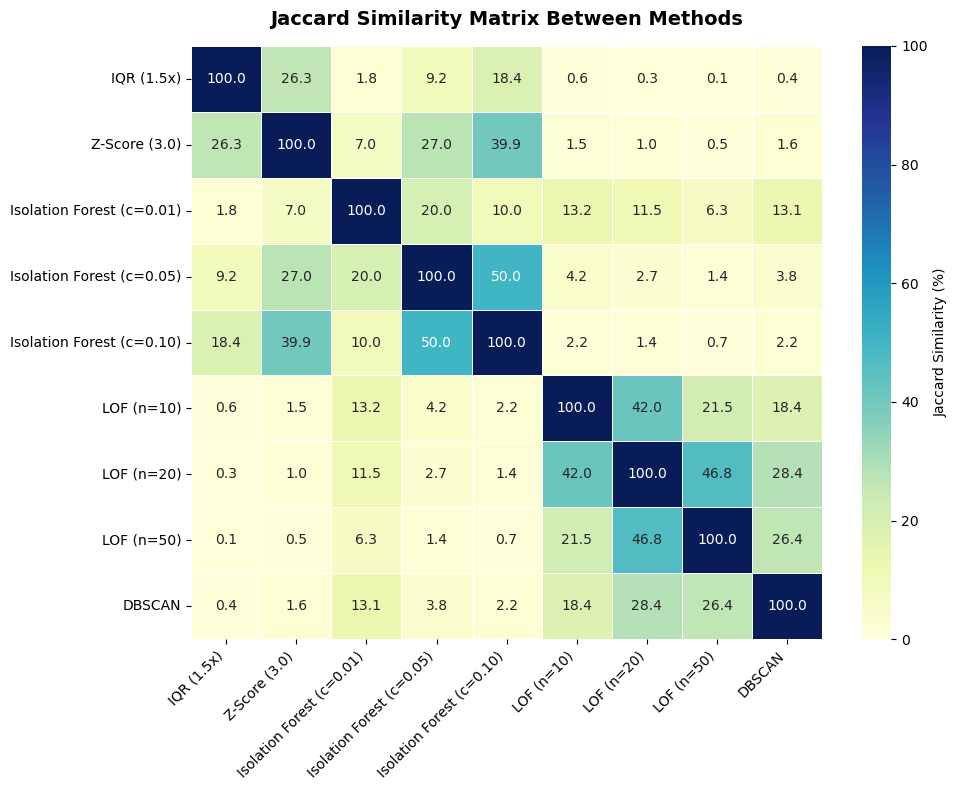

In [12]:
matrix_size = len(method_names)
jaccard_matrix = pd.DataFrame(np.eye(matrix_size) * 100, index=method_names, columns=method_names)

for _, row in df_jaccard.iterrows():
    m1, m2, sim = row["Method 1"], row["Method 2"], row["Jaccard Similarity (%)"]
    jaccard_matrix.loc[m1, m2] = sim
    jaccard_matrix.loc[m2, m1] = sim

plt.figure(figsize=(10, 8))
sns.heatmap(
    jaccard_matrix, 
    annot=True,         
    fmt=".1f",          
    cmap="YlGnBu",       # Bảng màu: Vàng (thấp) -> Xanh đậm (cao)
    vmin=0, vmax=100,    
    linewidths=0.5, 
    cbar_kws={'label': 'Jaccard Similarity (%)'}
)

plt.title("Jaccard Similarity Matrix Between Methods", fontsize=14, pad=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Dựa vào biểu đồ Heatmap và bảng xếp hạng **Jaccard Similarity**, chúng ta có thể rút ra một số nhận xét:
- Các thuật toán cùng họ với nhau có sự đồng bộ rất lớn, đây là một điểm không bất ngờ khi dĩ nhiên các cấu hình của cùng một thuật toán có sự chồng chéo cao nhất. Nhóm **Isolation Forest (c=0.05 và c=0.10)** đạt độ tương đồng đến **50%**, trong khi nhóm **LOF (n=20 và n=50)** đạt **46.8%**. Điều này chứng tỏ sự ổn định của thuật toán khi việc thay đổi tham số chỉ làm mở rộng hoặc thu hẹp tầm hoạt động của việc bắt được các giá trị ngoại lai, chứ không làm thay đổi hoàn toàn mục tiêu mà bản chất thuật toán đó nhắm tới.

- **DBSCAN** có độ đồng thuận khá tốt với các phương pháp thuộc nhóm **LOF**, nổi bật là **LOF (n=20)** với tỷ lệ **28.4%**. Điều này cho thấy cả 2 phương pháp tập trumg đánh giá độ bất thường của một dự án xây dựng dựa trên các dự án lân cận nó và có xác suất không nhỏ xác định đúng một nhóm các công trình xây dựng thực sự dị biệt so với môi trường xung quanh.

- Phương pháp **Z-Score (với `threshold = 3.0`)** lại có độ chồng chéo tương đối cao với **Isolation Forest (c=0.10)** lên tới **39.9%**, và với **Isolation Forest (c=0.05)** là **27.0%**. Có thể thấy **Z-Score** có ý tưởng tìm kiếm các giá trị cực đoan cách xa giá trị trung bình, trong khi đó **Isolation Forest** thì dùng các nhát cắt ngẫu nhiên và cô lập ranhững điểm nằm độc lập ở rìa ngoài cùng của không gian dữ liệu. Hệ quả là, cả hai phương pháp này lại có xu hướng cùng lấy được chung một nhóm các siêu dự án vĩ mô nằm ở phần đuôi xa nhất của phân phối chi phí.

- Còn **IQR** gần như thể hiện sự riêng biệt với các nhóm phương pháp còn lại (chỉ số **Jaccard Similarity** với **LOF** và **DBSCAN** chỉ ở mức 0.1% - 0.6%). Điều này thể hiện sự khác biệt về mặt bản chất của 2 bên nhóm phương pháp – một bên cắt theo ngưỡng cứng phân vị, một bên xét theo mật độ điểm – dẫn đến việc hai nhóm này gần như không nhìn chung về một hướng.

<a id="sec-2-3"></a>

## 2.3. Phân tích các điểm đáng tin cậy (Điểm được nhiều phương pháp lựa chọn là điểm ngoại lai)

Trong một tập dữ liệu, có những điểm chỉ bị một thuật toán duy nhất đánh dấu (do sai số hoặc do thuật toán đó quá khắt khe hoặc ngược lại). Tuy nhiên, nếu một điểm dữ liệu bị đánh dấu là ngoại lai bởi **nhiều phương pháp khác nhau** (thống kê, học máy, mật độ), thì độ tin cậy (Confidence) của điểm đó là cực kỳ cao.

Bước đầu tiên, chúng ta sẽ đếm tần suất xuất hiện của từng dòng dữ liệu trong các danh sách ngoại lai đã thu được ở các bước trước. 

Ở đây là lưu tất cả các index của ngoại lai ở tất cả các phương pháp vào 1 list duy nhất.

In [30]:
all_outlier_indices = []
for method_name, indices in outlier_indices_dict.items():
    all_outlier_indices.extend(indices)

# Đếm số lần xuất hiện của từng index
index_counts = Counter(all_outlier_indices)

# Chuyển kết quả thành DataFrame 
df_outlier_freq = pd.DataFrame(
    list(index_counts.items()),
    columns=['Row Index', 'Detection Count']
).sort_values(by='Detection Count', ascending=False)

Bây giờ thì tiến hành thống kê kết quả

In [32]:
summary_counts = df_outlier_freq['Detection Count'].value_counts().sort_index(ascending=False).to_frame(name='Number of Rows')
summary_counts.index.name = 'Detected by N Methods'

display(summary_counts)

,Number of Rows
Detected by N Methods,
9,116
8,49
7,94
6,219
5,1685
4,6077
3,7363
2,19044
1,73203


Dựa vào bảng thống kê phía trên, chúng ta sẽ thiết lập một ngưỡng đồng thuận (Consensus Threshold). Ở đây sẽ tập trung chọn những dòng dữ liệu bị đánh dấu bởi **cả 9 phương pháp** trở lên để trích xuất xem một số điểm tương đồng về bản chất của chúng là gì.

In [40]:
CONSENSUS_THRESHOLD = 9

golden_indices = df_outlier_freq[df_outlier_freq['Detection Count'] >= CONSENSUS_THRESHOLD]['Row Index'].tolist()

golden_outliers_data = dataset._origin_data.loc[golden_indices]

display(golden_outliers_data)

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
164303,201406239109,1,new construction,06/23/2014,4022,021,2070,NaN,Bryant,St,...,NaN,NaN,1.0,constr type 1,Y,9.0,Mission,94110.0,"(37.76104701285014, -122.41053835901573)",1346205395803
164304,201406239109,1,new construction,06/23/2014,4022,002,2028,NaN,Bryant,St,...,NaN,NaN,1.0,constr type 1,Y,9.0,Mission,94110.0,"(37.76133825052587, -122.41039295897379)",1346206168811
188488,201608054294,1,new construction,08/05/2016,3571,031,2050,NaN,Folsom,St,...,NaN,NaN,1.0,constr type 1,Y,9.0,Mission,94110.0,"(37.76428709483625, -122.41577351321943)",1486440510148
188489,201608054294,1,new construction,08/05/2016,3571,031,265,NaN,Shotwell,St,...,NaN,NaN,1.0,constr type 1,Y,9.0,Mission,94110.0,"(37.76428709483625, -122.41577351321943)",1486441510145
187666,201606200387,1,new construction,06/20/2016,3506,008,49,NaN,South Van Ness,Av,...,NaN,NaN,1.0,constr type 1,Y,6.0,Mission,94103.0,"(37.774145195939916, -122.41804210743528)",1485458510077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170927,201712277403,1,new construction,12/27/2017,5000,033,99,NaN,Harney,Wy,...,NaN,NaN,1.0,constr type 1,Y,10.0,Bayview Hunters Point,94124.0,"(37.71288703215362, -122.383163298689)",1491923510457
34271,201312184508,3,additions alterations or repairs,12/18/2013,0647,011,1670,NaN,Pine,St,...,NaN,NaN,1.0,constr type 1,Y,2.0,Western Addition,94109.0,"(37.789530212128774, -122.42346395757754)",132751977558
16708,201306210213,1,new construction,06/21/2013,4045,003,2171,NaN,03rd,St,...,NaN,NaN,1.0,constr type 1,Y,10.0,Potrero Hill,94107.0,"(37.762201026554685, -122.38825521841876)",1309100363320
148905,201602179822,1,new construction,02/17/2016,0331,011,238,NaN,Taylor,St,...,NaN,NaN,1.0,constr type 1,Y,6.0,Tenderloin,94102.0,"(37.78465846002597, -122.4106958449809)",1452168508474


Nhận xét qua các đặc điểm của các điểm đáng tin cậy này thống qua bảng thống kê tần suất và dữ liệu thực tế, chúng ta có thể rút ra những đánh giá cực kỳ giá trị về tập dữ liệu Giấy phép xây dựng:
- Trong tổng số gần 200000 dòng dữ liệu, có tới 73203 dòng chỉ bị phát hiện bởi 1 phương pháp duy nhất (rất có khả năng nằm ở **IQR** như đã phân tích). Tuy nhiên, khi tăng điều kiện lên mức đồng thuận tuyệt đối từ cả 9/9 cấu hình phương pháp), con số này chỉ còn đúng 116 dòng. Đây chính là những điểm những điểm dị biệt đến mức dù nhìn dưới lăng kính **Thống kê (Z-Score, IQR)**, **Cây quyết định (Isolation Forest)**, **Mật độ (LOF)** hay **Gom cụm (DBSCAN)**, chúng đều cho thấy sự nổi bật và tách biệt hoàn toàn so với phần còn lại của dữ liệu. Độ tin cậy của 116 điểm này là **100%**.

- Có thể nhận ra một số đặc điểm chung khi nhìn vào 10 dòng dữ liệu mẫu được trích xuất từ tập nguyên bản của 116 điểm này như sau:
    + `Permit Type Definition = "new construction"`: Trong khi phần lớn giấy phép xây dựng của thành phố là để sửa chữa, bảo trì, nâng cấp nhà ở hiện có, thì các điểm này đều là những dự án xây dựng mới hoàn toàn từ bãi đất trống.
    + `Proposed Construction Type = 1.0 ("constr type 1")`: Đây là chi tiết quan trọng nhất. Xét trên Domain Knowledge ở ngành xây dựng, Type 1 là loại công trình sử dụng vật liệu chống cháy cao nhất (thép, bê tông cốt thép chịu lực), thể hiện 1 điều rằng đây là các tòa nhà cao tầng (High-rises), chung cư thương mại quy mô lớn hoặc các tổ hợp văn phòng đắt tiền. Ở đó, các dự án này thường tập trung ở các khu vực trung tâm phát triển mạnh như **Mission**, **Tenderloin** hay **Mission Bay**.

$\rightarrow$ **Kết luận**: 116 điểm dữ liệu này **không phải là Noise hay lỗi nhập liệu (Errors)**. Chúng có thể là các **Siêu dự án (Mega-projects)** của thành phố với đặc thù là cần xây mới tòa nhà cao tầng từ đất trống nên chúng có số tầng lớn, thời gian phê duyệt dài, yêu cầu nhiều loại giấy phép phức tạp (`Site Permit = Y`) và đặc biệt là chi phí dự kiến khổng lồ. Việc sở hữu những đặc trưng chênh lệch hàng ngàn lần so với phần đông nhà dân dụng đã khiến chúng bị mọi thuật toán bắt lại. Có thể thấy, mếu mục tiêu của chúng ta là phân tích xu hướng hoặc dự đoán chi phí xây dựng chung, việc xóa bỏ đi 116 điểm này sẽ làm mất đi hoàn toàn bức tranh về mảng phát triển bất động sản quy mô lớn của thành phố, mà thay vào đó tách chúng ra thành một nhóm/cụm riêng biệt để xây dựng một mô hình dự đoán riêng, hoặc sử dụng cờ đánh dấu để giữ lại nguyên vẹn insight giá trị này.

<a id="sec-2-4"></a>

## 2.4. Tiến hành Kiểm định K-S (Kolmogorov-Smirnov Test) và Phân tích ý nghĩa của sự thay đổi phân phối
Sau khi đã xác định và loại bỏ ngoại lai bằng nhiều phương pháp khác nhau, câu hỏi tiếp theo đặt ra là: **"Việc loại bỏ các điểm này có làm thay đổi bản chất phân phối của dữ liệu hay không?"**

Để trả lời câu hỏi này, chúng ta sẽ sử dụng kiểm định **Kolmogorov-Smirnov (K-S Test)** với mức ý nghĩa `alpha = 0.05`.
* **Giả thuyết H0 (Null Hypothesis):** Dữ liệu gốc và dữ liệu sau khi làm sạch có cùng một phân phối (Việc loại bỏ ngoại lai không làm thay đổi phân phối).
* **Nếu P-value < 0.05:** Bác bỏ H0. Nghĩa là việc loại bỏ ngoại lai đã làm thay đổi đáng kể hình dáng phân phối của tập dữ liệu.

In [42]:
# Khởi tạo công cụ kiểm định K-S với mức ý nghĩa alpha = 0.05
ks_tester = KolmogorovSmirnovTesting(alpha=0.05)

# Khởi tạo danh sách lưu trữ kết quả
ks_results = []

Chúng ta sẽ lặp qua từng cấu hình thuật toán đã khởi tạo ở các phần trước. Với mỗi thuật toán, ta sẽ làm sạch một bản sao của dữ liệu (Clone Dataset), sau đó đưa cho `ks_tester` để so sánh phân phối giữa dữ liệu trước và sau khi xử lý.

In [43]:
for name, detector in detectors.items():
    start_time = time.time()
    print(f"Testing distribution change for: [{name}]")
    
    # Clone dữ liệu để đảm bảo không ghi đè lên dữ liệu gốc
    current_ds = dataset.clone()
    current_ds._origin_data = dataset._origin_data.copy()
    
    # Chạy thuật toán để loại bỏ ngoại lai trên bản clone
    detector.run(current_ds)
    
    # Chạy K-S Test (Công cụ tự động lấy _origin_data và data đã xử lý để so sánh)
    ks_tester.run(current_ds)
    
    # Thu thập kết quả
    ks_results.append({
        "Method": name,
        "KS Statistic": round(ks_tester.statistic, 4),
        "P-value": ks_tester.p_value,
        "H0 Rejected (p < 0.05)": ks_tester.is_rejected
    })
    
    elapsed = time.time() - start_time
    print(f"   => Completed in {elapsed:.2f} seconds.")

Testing distribution change for: [IQR (1.5x)]
   => Completed in 2.88 seconds.
Testing distribution change for: [Z-Score (3.0)]
   => Completed in 1.63 seconds.
Testing distribution change for: [Isolation Forest (c=0.01)]
   => Completed in 2.82 seconds.
Testing distribution change for: [Isolation Forest (c=0.05)]
   => Completed in 2.78 seconds.
Testing distribution change for: [Isolation Forest (c=0.10)]
   => Completed in 2.73 seconds.
Testing distribution change for: [LOF (n=10)]
   => Completed in 2.45 seconds.
Testing distribution change for: [LOF (n=20)]
   => Completed in 2.51 seconds.
Testing distribution change for: [LOF (n=50)]
   => Completed in 2.96 seconds.
Testing distribution change for: [DBSCAN]
   => Completed in 77.25 seconds.


Chuyển đổi danh sách kết quả thành DataFrame để ta có thể dễ dàng quan sát xem phương pháp nào làm thay đổi phân phối, phương pháp nào không.

In [44]:
df_ks_results = pd.DataFrame(ks_results)

print("Kolmogorov-Smirnov Test Summary Results:")
display(df_ks_results)

Kolmogorov-Smirnov Test Summary Results:


,Method,KS Statistic,P-value,H0 Rejected (p < 0.05)
0,IQR (1.5x),0.0213,1.407350e-295,True
1,Z-Score (3.0),0.0071,4.558286e-49,True
2,Isolation Forest (c=0.01),0.0023,4.162568e-06,True
3,Isolation Forest (c=0.05),0.0080,1.040108e-66,True
4,Isolation Forest (c=0.10),0.0124,8.283185e-155,True
5,LOF (n=10),0.0003,9.998717e-01,False
6,LOF (n=20),0.0002,1.000000e+00,False
7,LOF (n=50),0.0001,1.000000e+00,False
8,DBSCAN,0.0004,9.861003e-01,False


Có thể thấy, kết quả kiểm định **Kolmogorov-Smirnov (K-S Test)** mang lại một bức tranh cực kỳ rõ nét về mức độ ảnh hưởng tích cực hay tiêu cực của các thuật toán đối với bản chất gốc của dữ liệu Giấy phép xây dựng:
- Đối với **nhóm làm biến dạng dữ liệu (IQR, Z-Score, Isolation Forest - Bác bỏ H0)**: Điểm chung là **P-value gần như bằng 0 (nhỏ hơn $\alpha = 0.05$ rất nhiều)**. Do đó, giả thuyết H0 bị bác bỏ hoàn toàn. Nó đem đến ý nghĩa là việc loại bỏ các điểm mà **IQR**, **Z-Score** hay **Isolation Forest** cho là ngoại lai đã làm thay đổi nền tảng phân phối xác suất của tập dữ liệu, thậm chí là thay đổi bản chất dữ liệu theo cách chúng ta không hề mong muốn. Như đã phân tích trước đó, các phương pháp này đã gọt bỏ đi hàng chục ngàn dự án quy mô vừa và lớn (những dự án lệch phải). Việc cắt đi phần đuôi của phân phối này là một hệ quả tiêu cực (gây bóp méo dữ liệu). Thay vì làm sạch nhiễu, các phương pháp này đã biến dữ liệu của một đô thị sầm uất thành một vùng nông thôn đồng nhất, và bất kỳ mô hình Machine Learning nào học trên tập dữ liệu bị cắt gọt này sẽ không thể nào có khả năng dự đoán các dự án lớn.

- Ở **nhóm bảo tồn dữ liệu (LOF, DBSCAN - Chấp nhận H0)**: Kết quả là toàn bộ các cấu hình của **LOF** và **DBSCAN** đều trả về **P-value rất cao (gần bằng 1.0)**, do đó mà giả thuyết H0 cũng được chấp nhận. Điều này cho thấy việc loại bỏ vài trăm điểm ngoại lai bằng **LOF** hay **DBSCAN** hoàn toàn không làm thay đổi một cách rõ ràng hình dáng phân phối gốc của gần 200000 dòng dữ liệu. Điều này cho thấy sức mạnh của các thuật toán mật độ khi có thể đi sâu vào từng ngóc ngách không gian dữ liệu để lấy ra những điểm nhiễu thực sự (như lỗi nhập liệu, hoặc các ca cá biệt vô lý) mà không đụng chạm đến cấu trúc vĩ mô của toàn bộ thị trường xây dựng. Đây là một bước làm sạch tích cực và an toàn.

$\rightarrow$ Vậy nên, kết luận của chúng ta là với tập dữ liệu Building Permits, từ phương pháp **K-S Test** đã khẳng định nên dùng **LOF** hoặc **DBSCAN** để làm sạch các lỗi nhỏ nhặt trong tập dữ liệu một cách đúng đắn, và tuyệt đối không dùng **IQR** hay **Z-Score** để cắt gọt dữ liệu trừ khi đã áp dụng các phép biến đổi toán học (như Log-transform) từ trước.